# Imports

In [1]:
import pandas as pd
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_colwidth', None)

In [2]:
DETESTS_DIS_REPO_URL = "CLiC-UB/DETESTS-Dis"
LEVEL_4_DETESTS_DIS = "CLiC-UB/DETESTS-Dis-level4"

detests_dataset = load_dataset(DETESTS_DIS_REPO_URL, split="train")
level_4_detests_dataset = load_dataset(LEVEL_4_DETESTS_DIS, split="train")

detests_dataset_df = detests_dataset.to_pandas()
level_4_detests_df = level_4_detests_dataset.to_pandas()

# DETEST-Dis

## Data Distribution

In [3]:
sterotype_dis = detests_dataset_df["stereotype"].map({0: "No Stereotype", 1: "Stereotype"}).value_counts().sort_index()
implicit_dis = detests_dataset_df.loc[detests_dataset_df["stereotype"] == 1, "implicit"].map({0: "Explicit", 1: "Implicit"}).value_counts().sort_index()
stereotype_dis_soft = detests_dataset_df["stereotype_soft"].value_counts().sort_index()
implicit_dis_soft = detests_dataset_df.loc[detests_dataset_df["stereotype"] == 1, "implicit_soft"].value_counts().sort_index()

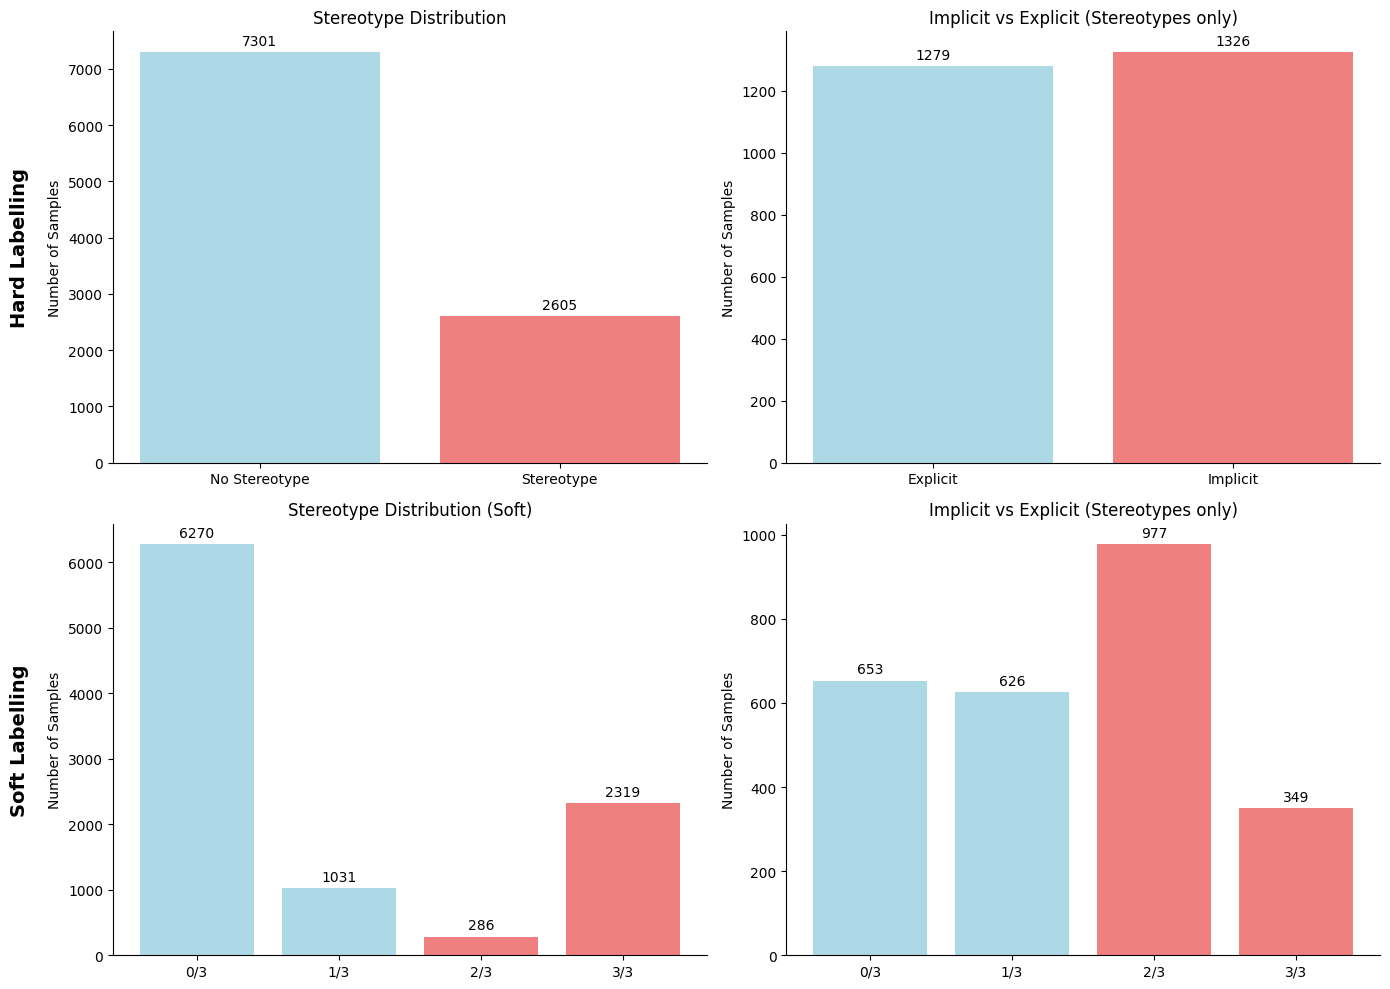

In [4]:
import os

# Increased figsize so the two rows don't overlap
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

# --- ROW 1: Hard Labelling ---

# Plot 1: Bar chart for Stereotype Distribution
bars1 = ax[0][0].bar(
    [str(i) for i in sterotype_dis.index], 
    sterotype_dis.values,
    color=['lightblue', 'lightcoral']
)
ax[0][0].set_title('Stereotype Distribution')
ax[0][0].set_ylabel('Number of Samples')
ax[0][0].bar_label(bars1, padding=3)

# Plot 2: Bar chart for Implicit Distribution
bars2 = ax[0][1].bar(
    [str(i) for i in implicit_dis.index], 
    implicit_dis.values,
    color=['lightblue', 'lightcoral']
)
ax[0][1].set_title('Implicit vs Explicit (Stereotypes only)')
ax[0][1].set_ylabel('Number of Samples')
ax[0][1].bar_label(bars2, padding=3)

# Add Row 1 Title on the left side
ax[0][0].annotate('Hard Labelling', xy=(0, 0.5), xytext=(-ax[0][0].yaxis.labelpad - 10, 0),
                  xycoords=ax[0][0].yaxis.label, textcoords='offset points',
                  size=14, ha='right', va='center', rotation=90, fontweight='bold')

# --- ROW 2: Soft Labelling ---

# Soft labels and colors as requested
soft_labels = ['0/3', '1/3', '2/3', '3/3']
soft_colors = ['lightblue', 'lightblue', 'lightcoral', 'lightcoral']

# Plot 3: Bar chart for Stereotype Distribution
bars3 = ax[1][0].bar(
    soft_labels, 
    stereotype_dis_soft.values,
    color=soft_colors
)
ax[1][0].set_title('Stereotype Distribution (Soft)')
ax[1][0].set_ylabel('Number of Samples')
ax[1][0].bar_label(bars3, padding=3)

# Plot 4: Bar chart for Implicit Distribution
bars4 = ax[1][1].bar(
    soft_labels, 
    implicit_dis_soft.values,
    color=soft_colors 
)
ax[1][1].set_title('Implicit vs Explicit (Stereotypes only)')
ax[1][1].set_ylabel('Number of Samples')
ax[1][1].bar_label(bars4, padding=3)

# Add Row 2 Title on the left side
ax[1][0].annotate('Soft Labelling', xy=(0, 0.5), xytext=(-ax[1][0].yaxis.labelpad - 10, 0),
                  xycoords=ax[1][0].yaxis.label, textcoords='offset points',
                  size=14, ha='right', va='center', rotation=90, fontweight='bold')


# Clean up axes for presentations (remove top and right borders)
# We need to flatten the 2D array of axes to iterate over them
for axis in ax.flatten():
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)

plt.tight_layout()

# Create directory if missing and save figure
os.makedirs("../figures", exist_ok=True)
fig.savefig("../figures/detest_dis_stereotype_distribution.png", dpi=300, transparent=True, bbox_inches='tight')

plt.show()

## Threads and Context Length

# EXIST

In [5]:
exists_dataset_training_df = pd.read_json("../data/EXIST2024_training.json", orient="index")
exists_dataset_training_df["labels_task1_soft"] = exists_dataset_training_df["labels_task1"].apply(lambda x: x.count("YES")/len(x))
exists_dataset_training_df["labels_task1_hard"] = exists_dataset_training_df["labels_task1"].apply(lambda x: 1 if x.count("YES") > 3 else 0 if x.count("YES") < 3 else 0.5)

In [6]:
from collections import Counter

def get_task3_hard_labels(row):
    # Count how many people voted YES on task 1
    num_yes = row["labels_task1"].count("YES")
    
    if num_yes == 0:
        return []

    # Flatten the lists of lists from all annotators, filtering out '-'
    all_votes = [label for annotator_labels in row["labels_task3"] for label in annotator_labels if label != '-']
    counts = Counter(all_votes)
    
    # Extract labels that have majority agreement among those who actually voted YES
    return [label for label, count in counts.items() if count > (num_yes / 2)]

def get_task3_soft_labels(row):
    # Count how many people voted YES on task 1
    num_yes = row["labels_task1"].count("YES")
    
    if num_yes == 0:
        return {}

    # Flatten the lists of lists from all annotators, filtering out '-'
    all_votes = [label for annotator_labels in row["labels_task3"] for label in annotator_labels if label != '-']
    counts = Counter(all_votes)
    # Calculate soft scores: votes / num_yes (so it's relative to those who voted yes)
    return {label: count / float(num_yes) for label, count in counts.items()}


# Apply to create a new column containing only the hard labels (list of labels)
exists_dataset_training_df["labels_task3_hard"] = exists_dataset_training_df.apply(get_task3_hard_labels, axis=1)

# Automatically create 0/1 columns for each unique hard label using pandas get_dummies
task3_dummies = exists_dataset_training_df["labels_task3_hard"].str.join('|').str.get_dummies()
task3_dummies.columns = [f"label_task3_{c}_hard" for c in task3_dummies.columns]

# Apply to compute soft labels (dictionary of category mapped to its fraction)
soft_labels_dicts = exists_dataset_training_df.apply(get_task3_soft_labels, axis=1)

# Expand the dictionaries into soft label columns (filling missing categories with 0.0)
task3_soft_df = pd.DataFrame(soft_labels_dicts.tolist(), index=exists_dataset_training_df.index).fillna(0.0)
task3_soft_df.columns = [f"label_task3_{c}_soft" for c in task3_soft_df.columns]

# Join back to dataset
exists_dataset_training_df = exists_dataset_training_df.join([task3_dummies, task3_soft_df])

# Display the first few rows showing the new columns
cols_to_show = ["labels_task3", "labels_task3_hard"] + list(task3_soft_df.columns)
exists_dataset_training_df[cols_to_show].head()

,labels_task3,labels_task3_hard,label_task3_OBJECTIFICATION_soft,label_task3_SEXUAL-VIOLENCE_soft,label_task3_STEREOTYPING-DOMINANCE_soft,label_task3_IDEOLOGICAL-INEQUALITY_soft,label_task3_MISOGYNY-NON-SEXUAL-VIOLENCE_soft,label_task3_UNKNOWN_soft
100001,"[[OBJECTIFICATION], [OBJECTIFICATION, SEXUAL-VIOLENCE], [-], [STEREOTYPING-DOMINANCE], [SEXUAL-VIOLENCE], [IDEOLOGICAL-INEQUALITY, MISOGYNY-NON-SEXUAL-VIOLENCE]]",[],0.400000,0.400000,0.20,0.2,0.2,0.0
100002,"[[-], [-], [-], [-], [OBJECTIFICATION], [-]]",[OBJECTIFICATION],1.000000,0.000000,0.00,0.0,0.0,0.0
100003,"[[-], [-], [-], [-], [-], [-]]",[],0.000000,0.000000,0.00,0.0,0.0,0.0
100004,"[[-], [-], [IDEOLOGICAL-INEQUALITY], [-], [IDEOLOGICAL-INEQUALITY], [IDEOLOGICAL-INEQUALITY, OBJECTIFICATION, SEXUAL-VIOLENCE]]",[IDEOLOGICAL-INEQUALITY],0.333333,0.333333,0.00,1.0,0.0,0.0
100005,"[[STEREOTYPING-DOMINANCE, OBJECTIFICATION], [-], [IDEOLOGICAL-INEQUALITY, OBJECTIFICATION], [-], [IDEOLOGICAL-INEQUALITY, STEREOTYPING-DOMINANCE], [STEREOTYPING-DOMINANCE, OBJECTIFICATION]]","[STEREOTYPING-DOMINANCE, OBJECTIFICATION]",0.750000,0.000000,0.75,0.5,0.0,0.0


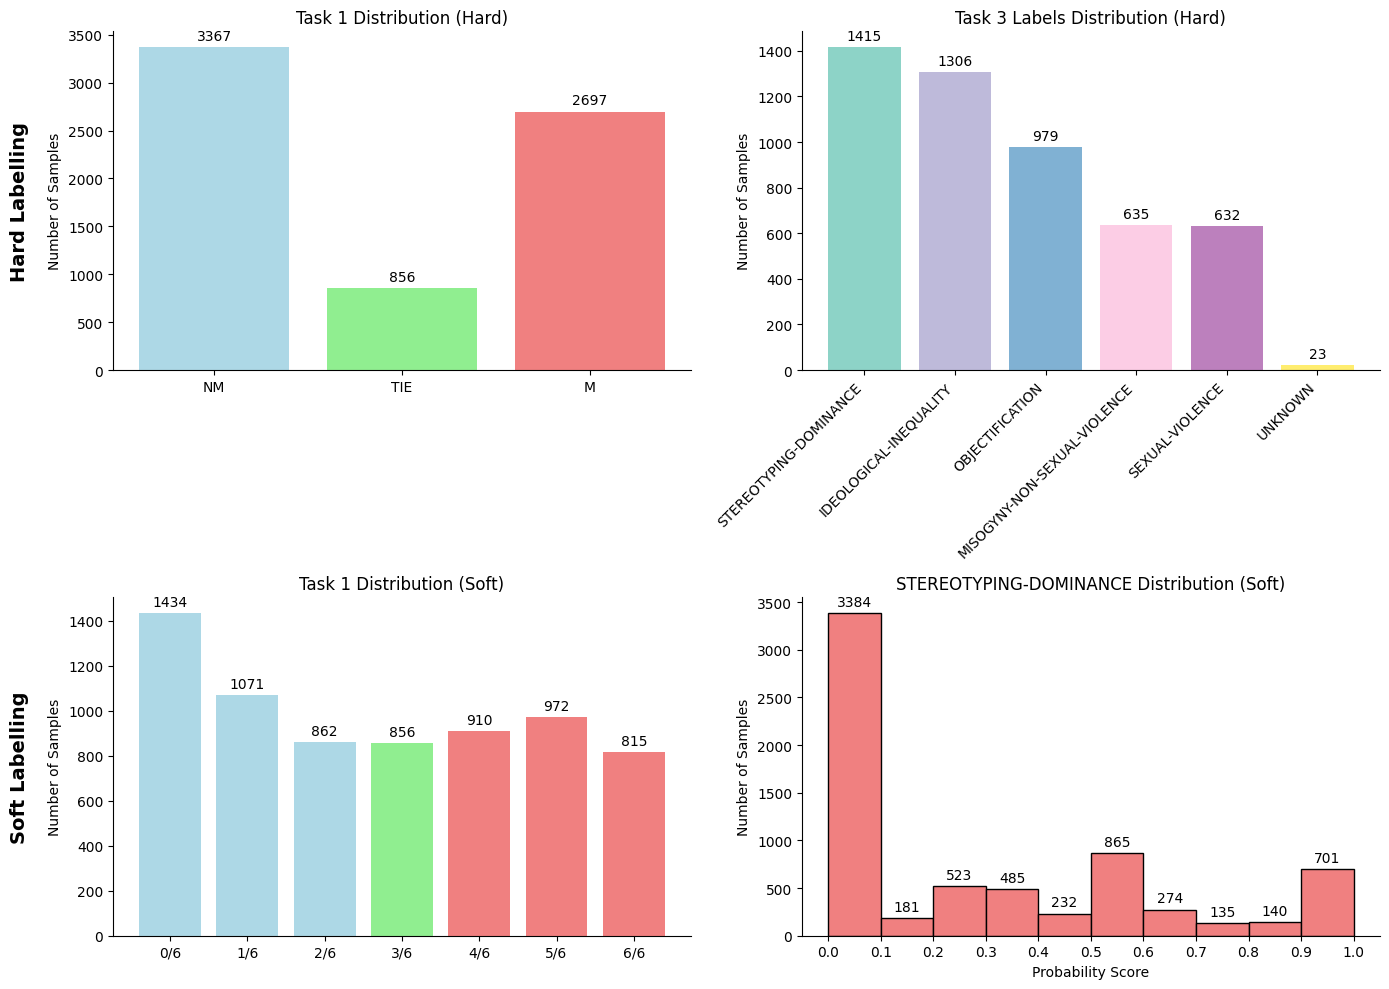

In [10]:
import os
import numpy as np

# Map Hard labels mapping 0 -> NM, 0.5 -> TIE, 1 -> M
# Using value_counts and reindexing to maintain strict order
exist_hard_dis = exists_dataset_training_df["labels_task1_hard"].map({0.0: "NM", 0.5: "TIE", 1.0: "M"}).value_counts()
exist_hard_dis = exist_hard_dis.reindex(["NM", "TIE", "M"]).fillna(0)

# Soft labels frequencies mapped to X/6 strings
# Since len(x) seems to be 6, multiplying by 6 gives the exact count of YES
exist_soft_counts = (exists_dataset_training_df["labels_task1_soft"] * 6).round().astype(int).value_counts()
exist_soft_labels = [f"{i}/6" for i in range(7)]
exist_soft_dis = exist_soft_counts.reindex(range(7)).fillna(0)
exist_soft_dis.index = exist_soft_labels

# Task 3 hard label counts
task3_cols = [col for col in exists_dataset_training_df.columns if col.startswith("label_task3_") and col.endswith("_hard")]
exist_task3_dis = exists_dataset_training_df[task3_cols].sum().sort_values(ascending=False)
# Strip "label_task3_" and "_hard" for the plot labels
exist_task3_dis.index = exist_task3_dis.index.str.replace("label_task3_", "").str.replace("_hard", "")

# Plotting on a 2x2 grid
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

# --- ROW 1: Hard Labelling ---

# Colors: NM (light blue), TIE (light green), M (light coral)
hard_colors = ['lightblue', 'lightgreen', 'lightcoral']

bars1 = ax[0][0].bar(
    exist_hard_dis.index, 
    exist_hard_dis.values,
    color=hard_colors
)
ax[0][0].set_title('Task 1 Distribution (Hard)')
ax[0][0].set_ylabel('Number of Samples')
ax[0][0].bar_label(bars1, padding=3)

# Plot Task 3 counts on the first row and second column with distinct colors per bar
# Generates a gradient or set of distinct colours
task3_colors = plt.cm.Set3(np.linspace(0, 1, len(exist_task3_dis)))

bars2 = ax[0][1].bar(
    exist_task3_dis.index, 
    exist_task3_dis.values,
    color=task3_colors
)
ax[0][1].set_title('Task 3 Labels Distribution (Hard)')
ax[0][1].set_ylabel('Number of Samples')
ax[0][1].tick_params(axis='x', rotation=45)
# Ensure rotated labels align nicely
for label in ax[0][1].get_xticklabels():
    label.set_ha('right')
ax[0][1].bar_label(bars2, padding=3)

# Add Row 1 Title on the left side
ax[0][0].annotate('Hard Labelling', xy=(0, 0.5), xytext=(-ax[0][0].yaxis.labelpad - 10, 0),
                  xycoords=ax[0][0].yaxis.label, textcoords='offset points',
                  size=14, ha='right', va='center', rotation=90, fontweight='bold')


# --- ROW 2: Soft Labelling ---

# Colors: [0/6..2/6] = lightblue, [3/6] = lightgreen, [4/6..6/6] = lightcoral
soft_colors = ['lightblue', 'lightblue', 'lightblue', 'lightgreen', 'lightcoral', 'lightcoral', 'lightcoral']

bars3 = ax[1][0].bar(
    exist_soft_dis.index, 
    exist_soft_dis.values,
    color=soft_colors
)
ax[1][0].set_title('Task 1 Distribution (Soft)')
ax[1][0].set_ylabel('Number of Samples')
ax[1][0].bar_label(bars3, padding=3)

# Task 3 specific Stereotyping dominance softly annotated distribution
# A histogram is more appropriate for continuous/semi-continuous soft probability distribution
st_dom_soft_col = "label_task3_STEREOTYPING-DOMINANCE_soft"
if st_dom_soft_col in exists_dataset_training_df.columns:
    counts, bins, patches = ax[1][1].hist(
        exists_dataset_training_df[st_dom_soft_col], 
        bins=np.arange(0, 1.1, 0.1), 
        color='lightcoral', 
        edgecolor='black'
    )
    ax[1][1].set_title('STEREOTYPING-DOMINANCE Distribution (Soft)')
    ax[1][1].set_ylabel('Number of Samples')
    ax[1][1].set_xlabel('Probability Score')
    ax[1][1].set_xticks(np.arange(0, 1.1, 0.1))
    ax[1][1].bar_label(patches, padding=3)
else:
    ax[1][1].text(0.5, 0.5, 'Data not found', horizontalalignment='center', verticalalignment='center')

# Add Row 2 Title on the left side
ax[1][0].annotate('Soft Labelling', xy=(0, 0.5), xytext=(-ax[1][0].yaxis.labelpad - 10, 0),
                  xycoords=ax[1][0].yaxis.label, textcoords='offset points',
                  size=14, ha='right', va='center', rotation=90, fontweight='bold')

# Clean up axes for presentations (remove top and right borders)
for axis in [ax[0][0], ax[0][1], ax[1][0], ax[1][1]]:
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)

plt.tight_layout()

# Create directory if missing and save figure
fig.savefig("../figures/exist_distributions.png", dpi=300, transparent=True, bbox_inches='tight')

plt.show()